# Equity Model Portfolio Review 2026 — TUK75/TUV100

**12 March 2026**

Annual review of equity model portfolios as required by fund terms, with focus on fee reduction opportunities as well as bringing model portfolio closer to the benchmark index considering the ESG restrictions.

**Fund covered:**
- **TUK75** (II pillar) and **TUV100** (III pillar) — identical iShares portfolios (5 holdings)

**Data sources:**
- Model portfolio weights — published fund documents
- ETF holdings (look-through) — downloaded from iShares website, pooled funds substituted by ETF equivalent
- ACWI benchmark — iShares MSCI ACWI ETF (SSAC) with sub-ETFs decomposed to stock level
- OCF data — pooled fund OCFs from BlackRock; public ETF TERs from fund factsheets

In [1]:
import sys
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import HTML, display

project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root / 'common' / 'scripts'))
from generate_charts import setup_plot_style, TULEVA_BLUE, TULEVA_NAVY, TULEVA_MID_BLUE

setup_plot_style()

# Brand colors
COLOR_OVERWEIGHT = TULEVA_NAVY
COLOR_UNDERWEIGHT = '#FF4800'
COLOR_NEUTRAL = '#B0B0B0'

# OCF dict (ISIN → bps) — TUK holdings only
OCF_BPS = {
    'IE00BFG1TM61': 5.5,   # iShares Developed World ESG Screened Index Fund (pooled)
    'IE0009FT4LX4': 5.5,   # CCF Developed World ESG Screened Index Fund (pooled)
    'IE00BFNM3G45': 7,     # iShares MSCI USA ESG Screened UCITS ETF
    'IE00BFNM3D14': 12,    # iShares MSCI Europe ESG Screened UCITS ETF
    'IE00BFNM3L97': 15,    # iShares MSCI Japan ESG Screened UCITS ETF
    'IE00BKPTWY98': 16,    # iShares EM Screened Equity Index Fund (pooled)
}

EM_COUNTRIES = {
    'China', 'Taiwan', 'India', 'Korea (South)', 'Brazil', 'South Africa',
    'Mexico', 'Saudi Arabia', 'Thailand', 'Indonesia', 'Malaysia', 'Philippines',
    'Turkey', 'Poland', 'Chile', 'Qatar', 'United Arab Emirates', 'Kuwait',
    'Colombia', 'Peru', 'Czech Republic', 'Egypt', 'Greece', 'Hungary',
}


def scrollable_table(df, title='', max_height=400, fmt=None):
    """Render a DataFrame as a scrollable HTML table."""
    styled = df.style
    if fmt:
        styled = styled.format(fmt)
    styled = styled.set_table_styles([
        {'selector': 'th', 'props': [('position', 'sticky'), ('top', '0'),
                                      ('background', '#002F63'), ('color', 'white'),
                                      ('padding', '6px 10px'), ('font-size', '0.85em')]},
        {'selector': 'td', 'props': [('padding', '4px 10px'), ('font-size', '0.85em'),
                                      ('border-bottom', '1px solid #eee')]},
        {'selector': 'tr:hover td', 'props': [('background', '#f5f5f5')]},
    ])
    html = styled.to_html()
    title_html = f'<h4 style="margin: 15px 0 5px 0;">{title}</h4>' if title else ''
    footer = f'<p style="color: #666; font-size: 0.85em; margin: 3px 0 15px 0;">{len(df)} rows</p>'
    return HTML(f'{title_html}<div style="max-height: {max_height}px; overflow-y: auto; '
                f'border: 1px solid #ddd; margin: 5px 0;">{html}</div>{footer}')


def metric_box(label, value, note=''):
    """Render a key metric as styled HTML."""
    note_html = f'<p style="color:#666; font-size:0.85em; margin:3px 0 0 0;">{note}</p>' if note else ''
    return HTML(f'<div style="background:#f8f9fa; border-left:4px solid #002F63; padding:12px 16px; '
                f'margin:10px 0; border-radius:0 4px 4px 0;">'
                f'<span style="font-size:0.9em; color:#666;">{label}</span><br>'
                f'<span style="font-size:1.8em; font-weight:bold; color:#002F63;">{value}</span>'
                f'{note_html}</div>')


def load_ishares_csv(fname):
    """Load iShares holdings from locally downloaded CSV file."""
    text = (data_dir / 'tkf_holdings' / fname).read_text(encoding='utf-8-sig')
    lines = text.splitlines()
    date_line = lines[0] if lines else ''
    holdings_date = date_line.split(',')[1].strip().strip('"') if ',' in date_line else None
    csv_start = next(i for i, l in enumerate(lines) if l.startswith('Ticker,'))
    df = pd.read_csv(io.StringIO('\n'.join(lines[csv_start:])), thousands=',')
    df['Weight (%)'] = pd.to_numeric(df['Weight (%)'], errors='coerce')
    return df, holdings_date


# Load look-through CSVs (generated by active_share_tkf.ipynb)
data_dir = Path.cwd() / 'data'
tuk_lt = pd.read_csv(data_dir / 'tuk_look_through.csv')
ssac = pd.read_csv(data_dir / 'ssac_benchmark.csv')

print(f'Loaded: TUK {len(tuk_lt)} stocks ({tuk_lt["weight"].sum():.2f}%), SSAC {len(ssac)} stocks ({ssac["weight"].sum():.2f}%)')
print(f'Join key: stock_id (Ticker|Location)')

# Load ETF holdings for decomposition
etf_holdings = {}
for ticker, fname in [('SAAI', 'SAAI_holdings.csv'), ('SAWD', 'SAWD_holdings.csv'),
                       ('SASU', 'SASU_holdings.csv'), ('SAEU', 'SAEU_holdings.csv'),
                       ('SAJP', 'SAJP_holdings.csv')]:
    df, date = load_ishares_csv(fname)
    eq = df[df['Asset Class'] == 'Equity'].copy()
    eq['stock_id'] = eq.apply(lambda r: f"{r['Ticker']}|{r['Location']}", axis=1)
    etf_holdings[ticker] = set(eq['stock_id'])
    print(f'  {ticker}: {len(eq)} equities (as of {date})')

Loaded: TUK 2286 stocks (99.74%), SSAC 2376 stocks (100.00%)
Join key: stock_id (Ticker|Location)
  SAAI: 1741 equities (as of 10-Mar-26)
  SAWD: 1201 equities (as of 10/Mar/2026)
  SASU: 485 equities (as of 10/Mar/2026)
  SAEU: 378 equities (as of 10/Mar/2026)
  SAJP: 161 equities (as of 10/Mar/2026)


In [2]:
# TUK75 / TUV100 model portfolio (identical iShares portfolios)
# Source: https://tuleva.ee/wp-content/uploads/2025/07/20250301_Mudelportfell_Tuleva.pdf
tuk_portfolio = pd.DataFrame([
    {'name': 'iShares Developed World Screened Index Fund',  'isin': 'IE00BFG1TM61', 'weight': 29.54, 'region': 'Developed World'},
    {'name': 'CCF Developed World Screened Index Fund',      'isin': 'IE0009FT4LX4', 'weight': 29.54, 'region': 'Developed World'},
    {'name': 'iShares MSCI USA ESG Screened UCITS ETF',      'isin': 'IE00BFNM3G45', 'weight': 22.63, 'region': 'US'},
    {'name': 'iShares MSCI Europe ESG Screened UCITS ETF',   'isin': 'IE00BFNM3D14', 'weight':  7.61, 'region': 'Europe'},
    {'name': 'iShares MSCI Japan ESG Screened UCITS ETF',    'isin': 'IE00BFNM3L97', 'weight':  0.80, 'region': 'Japan'},
    {'name': 'iShares EM Screened Equity Index Fund',        'isin': 'IE00BKPTWY98', 'weight':  9.89, 'region': 'Emerging Markets'},
])

# Join OCFs
tuk_portfolio['ocf_bps'] = tuk_portfolio['isin'].map(OCF_BPS)

# Compute weighted-average OCF
tuk_wavg_ocf = (tuk_portfolio['weight'] * tuk_portfolio['ocf_bps']).sum() / tuk_portfolio['weight'].sum()

print(f'TUK75/TUV100 weighted avg OCF: {tuk_wavg_ocf:.1f} bps')

TUK75/TUV100 weighted avg OCF: 7.4 bps


## 1. Current model portfolios

,name,isin,weight,ocf_bps
1,iShares Developed World Screened Index Fund,IE00BFG1TM61,29.5%,5.5
2,CCF Developed World Screened Index Fund,IE0009FT4LX4,29.5%,5.5
3,iShares MSCI USA ESG Screened UCITS ETF,IE00BFNM3G45,22.6%,7.0
4,iShares MSCI Europe ESG Screened UCITS ETF,IE00BFNM3D14,7.6%,12.0
5,iShares MSCI Japan ESG Screened UCITS ETF,IE00BFNM3L97,0.8%,15.0
6,iShares EM Screened Equity Index Fund,IE00BKPTWY98,9.9%,16.0


,Name,Weight %,Location,Sector
1,NVIDIA CORP,5.33,United States,Information Technology
2,APPLE INC,4.55,United States,Information Technology
3,MICROSOFT CORP,3.40,United States,Information Technology
4,AMAZON COM INC,2.45,United States,Consumer Discretionary
5,ALPHABET INC CLASS A,2.12,United States,Communication
6,BROADCOM INC,1.83,United States,Information Technology
7,ALPHABET INC CLASS C,1.78,United States,Communication
8,META PLATFORMS INC CLASS A,1.69,United States,Communication
9,TESLA INC,1.34,United States,Consumer Discretionary
10,TAIWAN SEMICONDUCTOR MANUFACTURING,1.31,Taiwan,Information Technology


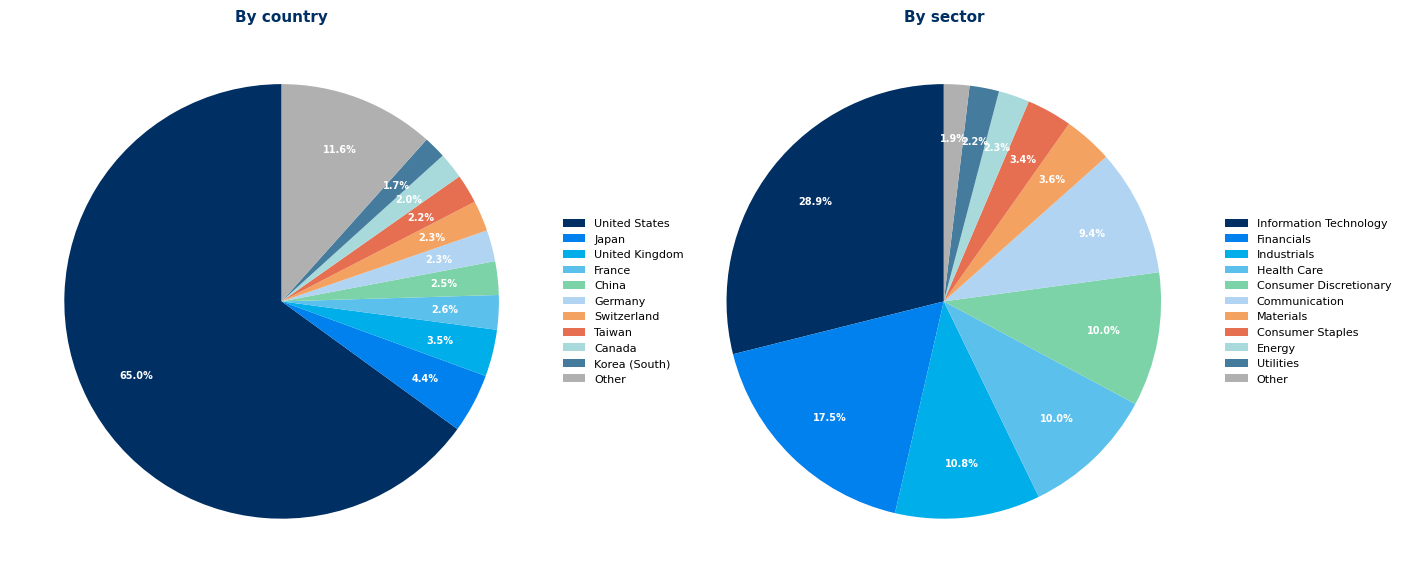

In [3]:
# --- TUK75 / TUV100 ---
tuk_display = tuk_portfolio[['name', 'isin', 'weight', 'ocf_bps']].copy()
tuk_display.index = range(1, len(tuk_display) + 1)
display(scrollable_table(tuk_display, title='TUK75 / TUV100 — Model Portfolio',
                         max_height=250, fmt={'weight': '{:.1f}%', 'ocf_bps': '{:.1f}'}))
display(metric_box('TUK75 / TUV100 — Weighted avg OCF', f'{tuk_wavg_ocf:.1f} bps'))

# --- Look-through holdings ---
tuk_lt_display = tuk_lt[['name', 'weight', 'location', 'sector']].copy()
tuk_lt_display.columns = ['Name', 'Weight %', 'Location', 'Sector']
tuk_lt_display = tuk_lt_display.sort_values('Weight %', ascending=False).reset_index(drop=True)
tuk_lt_display.index = range(1, len(tuk_lt_display) + 1)
display(scrollable_table(tuk_lt_display, title='TUK75 / TUV100 — Look-through holdings',
                         max_height=400, fmt={'Weight %': '{:.2f}'}))

# --- Pie charts: country and sector composition ---
# Top N + "Other" grouping
def top_n_other(series, n=10):
    top = series.nlargest(n)
    other = series.sum() - top.sum()
    if other > 0:
        top['Other'] = other
    return top

country_weights = tuk_lt.groupby('location')['weight'].sum().sort_values(ascending=False)
sector_weights = tuk_lt.groupby('sector')['weight'].sum().sort_values(ascending=False)

country_top = top_n_other(country_weights, 10)
sector_top = top_n_other(sector_weights, 10)

# Color palette
pie_colors = [TULEVA_NAVY, TULEVA_MID_BLUE, TULEVA_BLUE, '#5BC0EB', '#7DD3A8',
              '#B0D4F1', '#F4A261', '#E76F51', '#A8DADC', '#457B9D', '#B0B0B0']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title in [(ax1, country_top, 'By country'), (ax2, sector_top, 'By sector')]:
    wedges, texts, autotexts = ax.pie(
        data.values, labels=None, autopct='%1.1f%%',
        colors=pie_colors[:len(data)], startangle=90,
        pctdistance=0.75, textprops={'fontsize': 8},
    )
    for at in autotexts:
        at.set_fontsize(7)
        at.set_color('white')
        at.set_fontweight('bold')
    ax.legend(data.index, loc='center left', bbox_to_anchor=(1.0, 0.5),
              fontsize=8, frameon=False)
    ax.set_title(title, fontsize=11, fontweight='bold', color=TULEVA_NAVY)

plt.tight_layout()
plt.show()

In [4]:
# Compute active share: TUK vs SSAC (iShares ACWI)
# Active share = ½ × Σ|w_fund − w_bench|

merged = pd.merge(
    tuk_lt[['stock_id', 'name', 'weight', 'location', 'sector']],
    ssac[['stock_id', 'name', 'weight', 'location', 'sector']].rename(columns={'weight': 'weight_acwi', 'name': 'name_acwi', 'sector': 'sector_acwi'}),
    on='stock_id', how='outer',
)

# Fill names/location from benchmark for stocks only in SSAC
merged['name'] = merged['name'].fillna(merged['name_acwi'])
merged['location'] = merged['location_x'].fillna(merged['location_y'])
merged['sector'] = merged['sector'].fillna(merged['sector_acwi'])
merged.drop(columns=['name_acwi', 'location_x', 'location_y', 'sector_acwi'], inplace=True)

merged['weight'] = merged['weight'].fillna(0)
merged['weight_acwi'] = merged['weight_acwi'].fillna(0)

tuk_ids = set(tuk_lt['stock_id'])
ssac_ids = set(ssac['stock_id'])
merged['in_fund'] = merged['stock_id'].isin(tuk_ids)
merged['in_acwi'] = merged['stock_id'].isin(ssac_ids)
merged['diff'] = merged['weight'] - merged['weight_acwi']
merged['abs_diff'] = merged['diff'].abs()

active_share = merged['abs_diff'].sum() / 2
overlap = len(merged[merged['in_fund'] & merged['in_acwi']])

# --- Three-component decomposition ---

# 1. ESG exclusion: DM stocks in SSAC but not in SAAI (ESG-screened ACWI)
#    = sum of SSAC weights of excluded stocks (the active share SAAI vs SSAC)
#    Restricted to DM because EM stock_ids don't match reliably
#    (ssac_benchmark.csv decomposes sub-ETFs; SAAI lists EM stocks directly)
ssac_dm = ssac[~ssac['location'].isin(EM_COUNTRIES)]
ssac_dm_ids = set(ssac_dm['stock_id'])
saai_dm_ids = {sid for sid in etf_holdings['SAAI']
               if sid.split('|')[1] not in EM_COUNTRIES}
esg_excluded_ids = ssac_dm_ids - saai_dm_ids
esg_weights = ssac_dm.loc[ssac_dm['stock_id'].isin(esg_excluded_ids), 'weight']
esg_exclusion = esg_weights.sum()
esg_count = len(esg_excluded_ids)

# 2. Lower EM weight: TUK allocates 9.89% to EM vs SSAC's actual EM weight
em_weight_ssac = ssac.loc[ssac['location'].isin(EM_COUNTRIES), 'weight'].sum()
em_weight_tuk = tuk_portfolio.loc[tuk_portfolio['region'] == 'Emerging Markets', 'weight'].sum()
em_underweight = abs(em_weight_ssac - em_weight_tuk)

# 3. Partial replication: countries in SAWD not covered by regional ETFs
#    SASU=USA, SAEU=Europe, SAJP=Japan — missing: Canada, Australia, HK, etc.
#    Weight of missing countries in SAWD × regional ETF allocation share
sawd_df, _ = load_ishares_csv('SAWD_holdings.csv')
sawd_eq = sawd_df[sawd_df['Asset Class'] == 'Equity'].copy()
sasu_df, _ = load_ishares_csv('SASU_holdings.csv')
saeu_df, _ = load_ishares_csv('SAEU_holdings.csv')
sajp_df, _ = load_ishares_csv('SAJP_holdings.csv')
regional_countries = (set(sasu_df.loc[sasu_df['Asset Class'] == 'Equity', 'Location'])
                    | set(saeu_df.loc[saeu_df['Asset Class'] == 'Equity', 'Location'])
                    | set(sajp_df.loc[sajp_df['Asset Class'] == 'Equity', 'Location']))
missing_countries = set(sawd_eq['Location']) - regional_countries
missing_country_weight = sawd_eq.loc[sawd_eq['Location'].isin(missing_countries), 'Weight (%)'].sum()
tuk_regional_weight = tuk_portfolio.loc[tuk_portfolio['region'].isin(['US', 'Europe', 'Japan']), 'weight'].sum()
partial_replication = missing_country_weight * tuk_regional_weight / 100
missing_countries_str = ', '.join(sorted(missing_countries))

# Sum and residual
explained = esg_exclusion + em_underweight + partial_replication
residual = active_share - explained

decomp = pd.DataFrame([
    {'Component': f'ESG exclusions (DM)', 'Active Share %': esg_exclusion, 'Stocks': esg_count},
    {'Component': f'Lower EM weight ({em_weight_tuk:.1f}% vs SSAC)', 'Active Share %': em_underweight, 'Stocks': '-'},
    {'Component': 'Partial DM replication (regional ETFs)', 'Active Share %': partial_replication, 'Stocks': len(missing_countries)},
    {'Component': 'Other / interaction effects', 'Active Share %': residual, 'Stocks': '-'},
    {'Component': 'Total active share', 'Active Share %': active_share, 'Stocks': '-'},
]).set_index('Component')

print(f'TUK75/TUV100 active share: {active_share:.2f}%')
print(f'Overlap: {overlap} stocks, Fund-only: {len(merged[merged["in_fund"] & ~merged["in_acwi"]])}, ACWI-only: {len(merged[~merged["in_fund"] & merged["in_acwi"]])}')
print(f'\nDecomposition:')
print(f'  1. ESG exclusions (DM):    {esg_exclusion:.2f}% ({esg_count} stocks)')
print(f'  2. Lower EM weight:        {em_underweight:.2f}% (SSAC EM={em_weight_ssac:.1f}% vs TUK={em_weight_tuk:.1f}%)')
print(f'  3. Partial DM replication:  {partial_replication:.2f}% ({missing_country_weight:.1f}% of SAWD in {len(missing_countries)} missing countries x {tuk_regional_weight:.0f}% regional alloc)')
print(f'     Missing: {missing_countries_str}')
print(f'  4. Other/interaction:       {residual:.2f}%')

# Top overweight/underweight positions
top_ow = merged[merged['diff'] > 0].nlargest(15, 'diff')[['name', 'weight', 'weight_acwi', 'diff', 'location']].copy()
top_ow.columns = ['Stock', 'TUK %', 'ACWI %', 'Diff', 'Location']
top_ow.index = range(1, len(top_ow) + 1)

top_uw = merged[merged['diff'] < 0].nsmallest(15, 'diff')[['name', 'weight', 'weight_acwi', 'diff', 'location']].copy()
top_uw.columns = ['Stock', 'TUK %', 'ACWI %', 'Diff', 'Location']
top_uw.index = range(1, len(top_uw) + 1)

TUK75/TUV100 active share: 11.57%
Overlap: 2257 stocks, Fund-only: 29, ACWI-only: 119

Decomposition:
  1. ESG exclusions (DM):    7.15% (133 stocks)
  2. Lower EM weight:        1.68% (SSAC EM=11.6% vs TUK=9.9%)
  3. Partial DM replication:  1.96% (6.3% of SAWD in 6 missing countries x 31% regional alloc)
     Missing: Australia, Canada, Hong Kong, Israel, New Zealand, Singapore
  4. Other/interaction:       0.78%


## 2. Active share vs MSCI ACWI

Active share measures how much the portfolio differs from the MSCI ACWI benchmark at stock level. The largest source (7.2%) is the ESG screening applied by MSCI ESG Screened indices, which excludes 133 companies from the developed-market universe. The model portfolio allocates 9.9% to emerging markets vs 11.6% in ACWI, contributing 1.7%. Finally, the three regional ETFs (USA, Europe, Japan) that make up 31% of the portfolio do not cover Australia, Canada, Hong Kong, Israel, New Zealand, Singapore (6.3% of the developed-world index), adding 2.0%.

In [5]:
# --- Active share decomposition table ---
decomp_display = decomp.copy()
decomp_display.index = decomp_display.index.map(lambda x: f'  {x}' if x != 'Total active share' else x)

styled = decomp_display[['Active Share %']].style.format({'Active Share %': '{:.1f}%'})
styled = styled.set_table_styles([
    {'selector': 'th', 'props': [('background', '#002F63'), ('color', 'white'),
                                  ('padding', '8px 14px'), ('font-size', '0.9em'), ('text-align', 'left')]},
    {'selector': 'td', 'props': [('padding', '6px 14px'), ('font-size', '0.9em'),
                                  ('border-bottom', '1px solid #eee')]},
])
styled = styled.set_properties(**{'font-weight': 'bold'}, subset=pd.IndexSlice['Total active share', :])

display(HTML(styled.to_html()))

# --- Absent positions (in ACWI but not in TUK) ---
absent = merged[(merged['weight'] == 0) & (merged['weight_acwi'] > 0)].copy()
absent_display = absent.nlargest(10, 'weight_acwi')[['name', 'weight_acwi', 'location', 'sector']].copy()
absent_display.columns = ['Stock', 'ACWI %', 'Location', 'Sector']
absent_display.index = range(1, len(absent_display) + 1)
display(scrollable_table(absent_display, title=f'Largest absent positions ({len(absent)} stocks not in portfolio)',
                         max_height=350, fmt={'ACWI %': '{:.2f}'}))

# --- Absent positions by sector ---
absent_by_sector = absent.groupby('sector').agg(
    stocks=('stock_id', 'count'),
    weight=('weight_acwi', 'sum')
).sort_values('weight', ascending=False).reset_index()
absent_by_sector.columns = ['Sector', 'Stocks', 'ACWI weight %']
absent_by_sector.index = range(1, len(absent_by_sector) + 1)
display(scrollable_table(absent_by_sector, title='Absent positions by sector',
                         max_height=350, fmt={'ACWI weight %': '{:.2f}'}))

,Active Share %
Component,
ESG exclusions (DM),7.1%
Lower EM weight (9.9% vs SSAC),1.7%
Partial DM replication (regional ETFs),2.0%
Other / interaction effects,0.8%
Total active share,11.6%


,Stock,ACWI %,Location,Sector
1,CHEVRON CORP,0.38,United States,Energy
2,PROCTER & GAMBLE,0.38,United States,Consumer Staples
3,COCA-COLA,0.34,United States,Consumer Staples
4,RTX CORP,0.29,United States,Industrials
5,NESTLE LTD,0.28,Switzerland,Consumer Staples
6,PHILIP MORRIS INTERNATIONAL INC,0.28,United States,Consumer Staples
7,SHELL PLC,0.26,United Kingdom,Energy
8,PEPSICO INC,0.23,United States,Consumer Staples
9,BOEING,0.18,United States,Industrials
10,HONEYWELL INTERNATIONAL INC,0.16,United States,Industrials


,Sector,Stocks,ACWI weight %
1,Consumer Staples,17,2.38
2,Energy,27,1.82
3,Industrials,17,1.58
4,Utilities,21,0.82
5,Materials,13,0.45
6,Consumer Discretionary,7,0.22
7,Financials,3,0.07
8,Health Care,3,0.07
9,Information Technology,2,0.03
10,Communication,1,0.01


## 3. Proposal: increase EM allocation to match ACWI

Increasing the EM allocation from 9.9% to 11.6% (matching ACWI) eliminates the 1.7% EM underweight component of active share, reducing it from 11.6% to 9.9%. The cost is a small increase in weighted-average OCF from 7.4 to 7.6 bps, since the EM fund (16 bps) is the most expensive holding. The DM reductions are proportional to each holding's current weight.

In [6]:
# Proposal: increase EM to match ACWI weight, funded proportionally from DM holdings

em_increase = em_weight_ssac - em_weight_tuk

# Current DM weights
dm_holdings = tuk_portfolio[tuk_portfolio['region'] != 'Emerging Markets'].copy()
sum_dm_weights = dm_holdings['weight'].sum()

# Build proposed portfolio
proposed = tuk_portfolio.copy()
for idx in proposed.index:
    if proposed.loc[idx, 'region'] == 'Emerging Markets':
        proposed.loc[idx, 'proposed_weight'] = proposed.loc[idx, 'weight'] + em_increase
    else:
        current_w = proposed.loc[idx, 'weight']
        proposed.loc[idx, 'proposed_weight'] = current_w - em_increase * (current_w / sum_dm_weights)

proposed['change'] = proposed['proposed_weight'] - proposed['weight']

# New weighted-avg OCF
proposed_wavg_ocf = (proposed['proposed_weight'] * proposed['ocf_bps']).sum() / proposed['proposed_weight'].sum()

# Active share impact: EM underweight component drops to ~0
proposed_active_share = active_share - em_underweight

# Comparison table
comparison = proposed[['name', 'weight', 'proposed_weight', 'change', 'ocf_bps']].copy()
comparison.columns = ['Holding', 'Current %', 'Proposed %', 'Change', 'OCF (bps)']
comparison.index = range(1, len(comparison) + 1)

# Add total row
total_row = pd.DataFrame([{
    'Holding': 'Total',
    'Current %': comparison['Current %'].sum(),
    'Proposed %': comparison['Proposed %'].sum(),
    'Change': comparison['Change'].sum(),
    'OCF (bps)': np.nan,
}], index=[len(comparison) + 1])
comparison = pd.concat([comparison, total_row])

print(f'EM increase: {em_increase:.2f}pp (from {em_weight_tuk:.2f}% to {em_weight_ssac:.1f}%)')
print(f'Current OCF: {tuk_wavg_ocf:.1f} bps → Proposed OCF: {proposed_wavg_ocf:.1f} bps (+{proposed_wavg_ocf - tuk_wavg_ocf:.2f} bps)')
print(f'Current active share: {active_share:.2f}% → Proposed: {proposed_active_share:.2f}%')

EM increase: 1.68pp (from 9.89% to 11.6%)
Current OCF: 7.4 bps → Proposed OCF: 7.6 bps (+0.16 bps)
Current active share: 11.57% → Proposed: 9.89%


In [7]:
# --- Comparison table ---
fmt = {'Current %': '{:.1f}', 'Proposed %': '{:.1f}', 'Change': '{:+.1f}', 'OCF (bps)': '{:.1f}'}
styled_comp = comparison.style.format(fmt, na_rep='')
styled_comp = styled_comp.set_table_styles([
    {'selector': 'th', 'props': [('background', '#002F63'), ('color', 'white'),
                                  ('padding', '8px 14px'), ('font-size', '0.9em'), ('text-align', 'left')]},
    {'selector': 'td', 'props': [('padding', '6px 14px'), ('font-size', '0.9em'),
                                  ('border-bottom', '1px solid #eee')]},
])
styled_comp = styled_comp.set_properties(**{'font-weight': 'bold'}, subset=pd.IndexSlice[len(comparison), :])

display(HTML(styled_comp.to_html()))

# --- Metric boxes side by side ---
ocf_change = proposed_wavg_ocf - tuk_wavg_ocf
as_change = proposed_active_share - active_share

metrics_html = f"""
<div style="display: flex; gap: 16px; flex-wrap: wrap; margin: 16px 0;">
  <div style="flex: 1; min-width: 250px; background:#f8f9fa; border-left:4px solid #002F63; padding:12px 16px; border-radius:0 4px 4px 0;">
    <span style="font-size:0.9em; color:#666;">Weighted avg OCF</span><br>
    <span style="font-size:1.8em; font-weight:bold; color:#002F63;">{proposed_wavg_ocf:.1f} bps</span>
    <p style="color:#666; font-size:0.85em; margin:3px 0 0 0;">Currently {tuk_wavg_ocf:.1f} bps (+{ocf_change:.2f} bps)</p>
  </div>
  <div style="flex: 1; min-width: 250px; background:#f8f9fa; border-left:4px solid #002F63; padding:12px 16px; border-radius:0 4px 4px 0;">
    <span style="font-size:0.9em; color:#666;">Estimated active share</span><br>
    <span style="font-size:1.8em; font-weight:bold; color:#002F63;">{proposed_active_share:.1f}%</span>
    <p style="color:#666; font-size:0.85em; margin:3px 0 0 0;">Currently {active_share:.1f}% ({as_change:.1f}pp)</p>
  </div>
</div>
"""
display(HTML(metrics_html))

# --- Signature ---
display(HTML("""<div style="margin-top: 40px; padding-top: 16px; border-top: 1px solid #ddd;">
  <p style="font-size: 0.9em; color: #333;">Prepared by Tõnu Pekk<br>12 March 2026</p>
</div>"""))

,Holding,Current %,Proposed %,Change,OCF (bps)
1,iShares Developed World Screened Index Fund,29.5,29.0,-0.6,5.5
2,CCF Developed World Screened Index Fund,29.5,29.0,-0.6,5.5
3,iShares MSCI USA ESG Screened UCITS ETF,22.6,22.2,-0.4,7.0
4,iShares MSCI Europe ESG Screened UCITS ETF,7.6,7.5,-0.1,12.0
5,iShares MSCI Japan ESG Screened UCITS ETF,0.8,0.8,-0.0,15.0
6,iShares EM Screened Equity Index Fund,9.9,11.6,+1.7,16.0
7,Total,100.0,100.0,+0.0,
